In [4]:
# Notebook setup
%load_ext autoreload
%autoreload 2
import os
import sys
nb_dir = os.path.split(os.getcwd())[0]
if nb_dir not in sys.path:
    sys.path.append(nb_dir)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import mne
from cerebra_atlas_python import CerebrA
import os.path as op

In [6]:
data_path = mne.datasets.sample.data_path()
subject = "sample"
data_dir = data_path / "MEG" / subject
fname_evoked = data_dir / f"{subject}_audvis-ave.fif"
fname_cov = data_dir / f"{subject}_audvis-shrunk-cov.fif"

In [7]:
condition = "Left Auditory"
noise_cov = mne.read_cov(fname_cov)
evoked = mne.read_evokeds(fname_evoked, condition=condition, baseline=(None, 0))

    365 x 365 full covariance (kind = 1) found.
    Read a total of 4 projection items:
        PCA-v1 (1 x 102) active
        PCA-v2 (1 x 102) active
        PCA-v3 (1 x 102) active
        Average EEG reference (1 x 59) active
Reading /home/carlos/mne_data/MNE-sample-data/MEG/sample/sample_audvis-ave.fif ...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102) active
        PCA-v2 (1 x 102) active
        PCA-v3 (1 x 102) active
        Average EEG reference (1 x 60) active
    Found the data of interest:
        t =    -199.80 ...     499.49 ms (Left Auditory)
        0 CTF compensation matrices available
        nave = 55 - aspect type = 100
Projections have already been applied. Setting proj attribute to True.
Applying baseline correction (mode: mean)


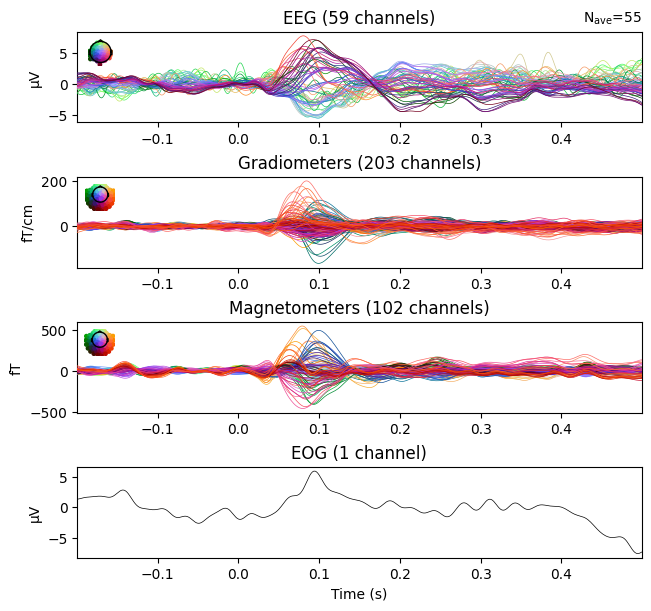

Computing rank from covariance with rank=None
    Using tolerance 2.8e-14 (2.2e-16 eps * 102 dim * 1.2  max singular value)
    Estimated rank (mag): 102
    MAG: rank 102 computed from 102 data channels with 0 projectors
Computing rank from covariance with rank=None
    Using tolerance 1.9e-13 (2.2e-16 eps * 203 dim * 4.2  max singular value)
    Estimated rank (grad): 203
    GRAD: rank 203 computed from 203 data channels with 0 projectors
Computing rank from covariance with rank=None
    Using tolerance 1.2e-13 (2.2e-16 eps * 60 dim * 8.7  max singular value)
    Estimated rank (eeg): 60
    EEG: rank 60 computed from 60 data channels with 0 projectors


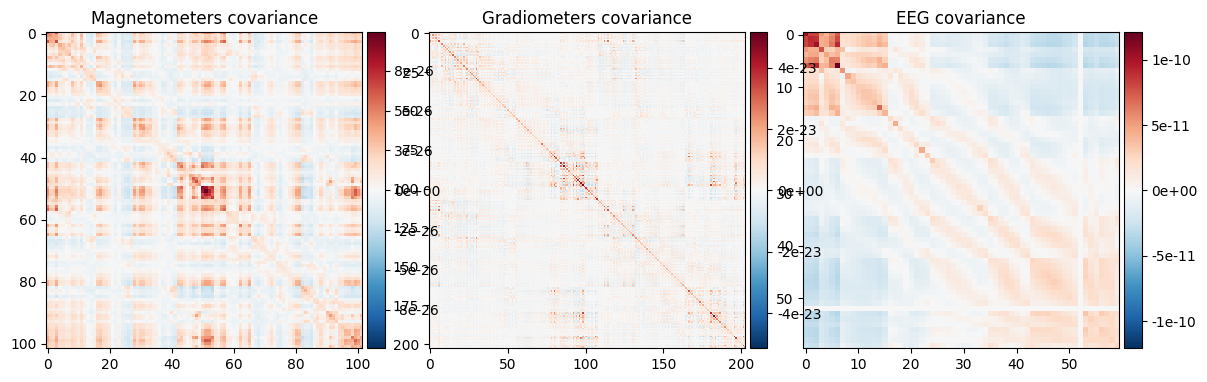

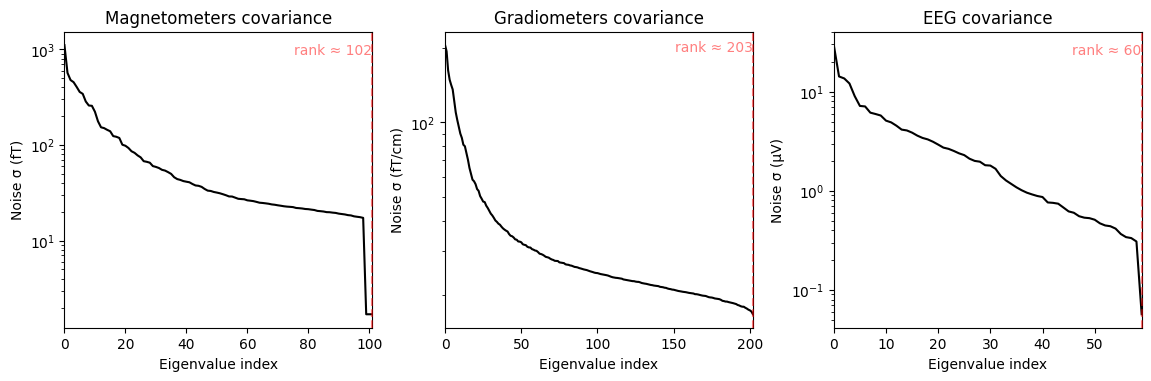

In [8]:
evoked.plot()
noise_cov.plot(evoked.info)
pass

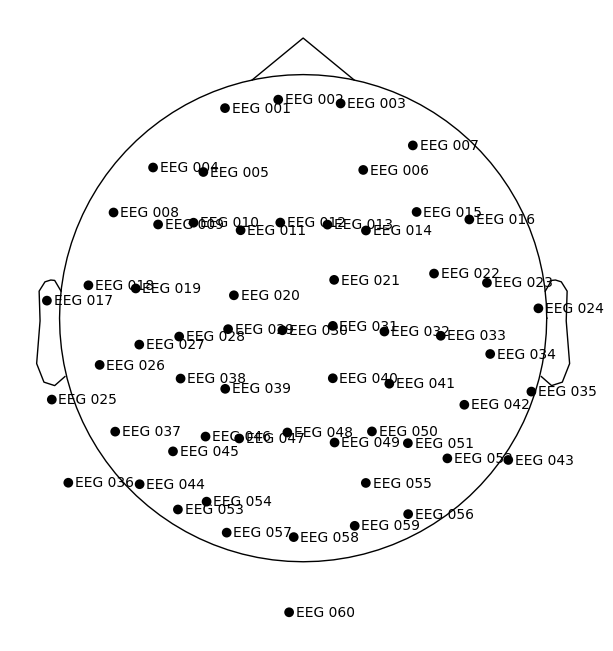

<DigMontage | 78 extras (headshape), 4 HPIs, 3 fiducials, 60 channels>

In [9]:
evoked.info.get_montage().plot()
pass
evoked.info.get_montage()

In [10]:
cerebra = CerebrA()

In [11]:
# Save info

# evoked.info.save("temp_info.fif")

mne.gui.coregistration(
    inst="temp_info.fif",
    subjects_dir=cerebra.cerebra_data.subjects_dir,
    block=True,
    subject=cerebra.cerebra_data.subject_name,
)

Using pyvistaqt 3d backend.


Fontconfig warning: "/usr/share/fontconfig/conf.avail/05-reset-dirs-sample.conf", line 6: unknown element "reset-dirs"


For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
    Triangle neighbors and vertex normals...
Using low resolution head model in /home/carlos/Carlos/cerebra_atlas_python/cerebra_atlas_python/data/cerebra_data/FreeSurfer/subjects/icbm152/bem/outer_skin.surf
    Triangle neighbors and vertex normals...
Using fiducials from: /home/carlos/Carlos/cerebra_atlas_python/cerebra_atlas_python/data/cerebra_data/FreeSurfer/subjects/icbm152/bem/icbm152-fiducials.fif.
    Triangle neighbors and vertex normals...
Using low resolution head model in /home/carlos/Carlos/cerebra_atlas_python/cerebra_atlas_python/data/cerebra_data/FreeSurfer/subjects/icbm152/bem/outer_skin.surf
    Triangle neighbors and vertex normals...
Using fiducials from: /home/carlos/Carlos/cerebra_atlas_python/cerebra_atlas_python/data/cerebra_data/FreeSur

In [12]:
trans = mne.read_trans("test_trans.fif")

In [13]:
from cerebra_atlas_python.cerebra_mne.mne_forward import _get_forward

In [14]:
snr = 3.0  # use smaller SNR for raw data
inv_method = "dSPM"  # sLORETA, MNE, dSPM
cerebra = CerebrA()


fwd = _get_forward(trans, cerebra.src_space, cerebra.bem, evoked.info)

Computing src space...
BEM              : <ConductorModel | BEM (3 layers) solver=mne>
Source location file  : dict()
Assuming input in millimeters
Assuming input in MRI coordinates

Positions (in meters) and orientations
31553 sources
Source space          : <SourceSpaces: [<discrete, n_used=31553>] MRI (surface RAS) coords, ~1.9 MiB>
MRI -> head transform : instance of Transform
Measurement data      : instance of Info
Conductor model   : instance of ConductorModel
Accurate field computations
Do computations in head coordinates
Free source orientations

Read 1 source spaces a total of 31553 active source locations

Coordinate transformation: MRI (surface RAS) -> head
    0.995827 -0.002177 -0.091235      -2.53 mm
    0.007150 0.998503 0.054226      13.07 mm
    0.090980 -0.054652 0.994352      60.05 mm
    0.000000 0.000000 0.000000       1.00

Read  60 EEG channels from info
Head coordinate coil definitions created.
Source spaces are now in head coordinates.

Employing the head->MRI

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


    Found     0/18601 points outside using solid angles
    Total 31553/31553 points inside the surface
Interior check completed in 1828.8 ms



[Parallel(n_jobs=-1)]: Done   6 out of  24 | elapsed:    1.6s remaining:    4.9s
[Parallel(n_jobs=-1)]: Done  11 out of  24 | elapsed:    1.7s remaining:    2.0s
[Parallel(n_jobs=-1)]: Done  16 out of  24 | elapsed:    1.7s remaining:    0.9s
[Parallel(n_jobs=-1)]: Done  21 out of  24 | elapsed:    1.7s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  24 out of  24 | elapsed:    1.8s finished


Setting up for EEG...
Computing EEG at 31553 source locations (free orientations)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  24 | elapsed:    1.5s remaining:    4.4s
[Parallel(n_jobs=-1)]: Done  11 out of  24 | elapsed:    1.7s remaining:    2.0s
[Parallel(n_jobs=-1)]: Done  16 out of  24 | elapsed:    2.0s remaining:    1.0s
[Parallel(n_jobs=-1)]: Done  21 out of  24 | elapsed:    2.2s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done  24 out of  24 | elapsed:    2.4s finished



Finished.


In [15]:
fwd["info"] = evoked.info
inverse = mne.minimum_norm.make_inverse_operator(
    evoked.info,
    fwd,
    noise_cov,
)

info["bads"] and noise_cov["bads"] do not match, excluding bad channels from both
Computing inverse operator with 59 channels.
    59 out of 60 channels remain after picking
Selected 59 channels
Creating the depth weighting matrix...
    59 EEG channels
    limit = 31554/31553 = 3.129950
    scale = 220275 exp = 0.8
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 1)
Computing rank from covariance with rank=None
    Using tolerance 1.1e-13 (2.2e-16 eps * 59 dim * 8.7  max singular value)
    Estimated rank (eeg): 58
    EEG: rank 58 computed from 59 data channels with 1 projector
    Setting small EEG eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
Computing SVD of whitened and weighted lead field matrix.
    largest singular value = 2.56063
    scaling factor to adjust the trace = 3.34055e+20 (nchan = 59 nzero = 1)


In [16]:
snr = 3.0  # use smaller SNR for raw data
lambda2 = 1.0 / snr**2
stc = mne.minimum_norm.apply_inverse(
    evoked, inverse, lambda2, inv_method, pick_ori=None
)

Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 55
    Created the regularized inverter
    Created an SSP operator (subspace dimension = 1)
    Created the whitener using a noise covariance matrix with rank 58 (1 small eigenvalues omitted)
    Computing noise-normalization factors (dSPM)...
[done]
Applying inverse operator to "Left Auditory"...
    Picked 59 channels from the data
    Computing inverse...
    Eigenleads need to be weighted ...
    Computing residual...
    Explained  84.2% variance
    Combining the current components...
    dSPM...
[done]


In [17]:
evoked.info["sfreq"]

600.614990234375

In [18]:
stc.tstep

0.0016649601096532323

In [19]:
stc.tmin * 1000

-199.79521315838787

In [20]:
import numpy as np

np.arange(stc.tmin * 1000, 500, stc.tstep * 1000).shape

(421,)

In [21]:
stc.data.shape

(31553, 421)

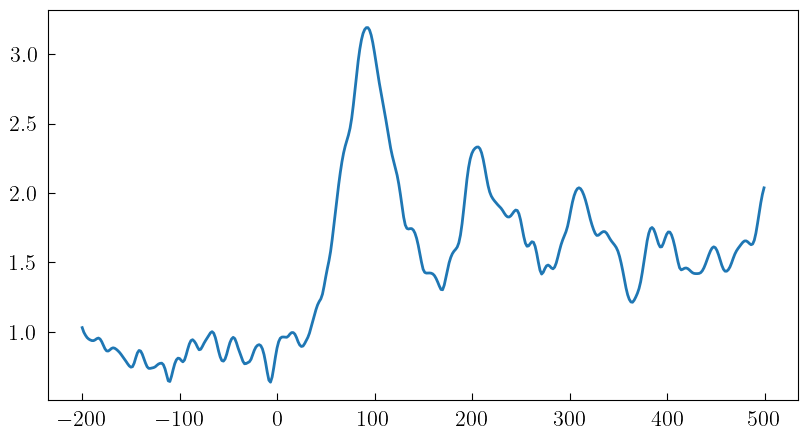

In [22]:
mean_src_space_act = stc.data.mean(axis=0)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(np.arange(stc.tmin * 1000, 500, stc.tstep * 1000), mean_src_space_act)

In [23]:
tmax_act = np.where(mean_src_space_act == mean_src_space_act.max())[0][0]
tmax_act

np.int64(176)

In [24]:
from cerebra_atlas_python.plotting.colors import apply_colormap

stc.data[:, tmax_act].shape

(31553,)

In [25]:
stc.data[:, tmax_act].max()

np.float64(8.459575134889837)

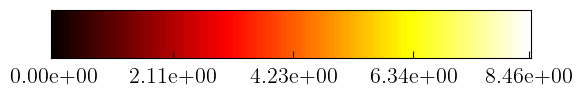

In [26]:
colors = apply_colormap(
    stc.data[:, tmax_act], "hot", vmin_vmax=(0, stc.data[:, tmax_act].max())
)

In [27]:
colors.shape

(31553, 3)

In [29]:
cerebra.plot_3d(colors)